<a href="https://colab.research.google.com/github/NinaNikolova/data_mining_project/blob/main/python_games_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SVM:
## LinearSVR

In [1]:
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files
uploaded = files.upload()

Mounted at /content/drive


Saving video_game_reviews.csv to video_game_reviews.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR, LinearSVR
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

from sklearn.svm import LinearSVC,  LinearSVR
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import joblib
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('/content/video_game_reviews.csv')
df.head()

,Game Title,User Rating,Age Group Targeted,Price,Platform,Requires Special Device,Developer,Publisher,Release Year,Genre,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,User Review Text,Game Mode,Min Number of Players
0,Grand Theft Auto V,36.4,All Ages,41.41,PC,No,Game Freak,Innersloth,2015,Adventure,No,55.3,Medium,Average,Poor,"Solid game, but too many bugs.",Offline,1
1,The Sims 4,38.3,Adults,57.56,PC,No,Nintendo,Electronic Arts,2015,Shooter,Yes,34.6,Low,Poor,Poor,"Solid game, but too many bugs.",Offline,3
2,Minecraft,26.8,Teens,44.93,PC,Yes,Bungie,Capcom,2012,Adventure,Yes,13.9,Low,Good,Average,"Great game, but the graphics could be better.",Offline,5
3,Bioshock Infinite,38.4,All Ages,48.29,Mobile,Yes,Game Freak,Nintendo,2015,Sports,No,41.9,Medium,Good,Excellent,"Solid game, but the graphics could be better.",Online,4
4,Half-Life: Alyx,30.1,Adults,55.49,PlayStation,Yes,Game Freak,Epic Games,2022,RPG,Yes,13.2,High,Poor,Good,"Great game, but too many bugs.",Offline,1


In [11]:
target = df["User Rating"]
attributes = df.drop(columns=["User Rating"]).select_dtypes(include=["number"])
# 3. Split the data into training and test sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(attributes, target, test_size=0.2, random_state=42)

# 4. Train the model
simple_svm = LinearSVR()
simple_svm.fit(X_train, y_train)


LinearSVR()

In [12]:
# 5. (Optional) Evaluate on test data
predictions = simple_svm.predict(X_test)

In [13]:
# 2. Evaluate performance
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)


In [14]:
# 3. Print the results
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.008960543046359
Mean Squared Error (MSE): 1.377302152722408
Root Mean Squared Error (RMSE): 1.1735851706298985
R² Score: 0.9762143956458197


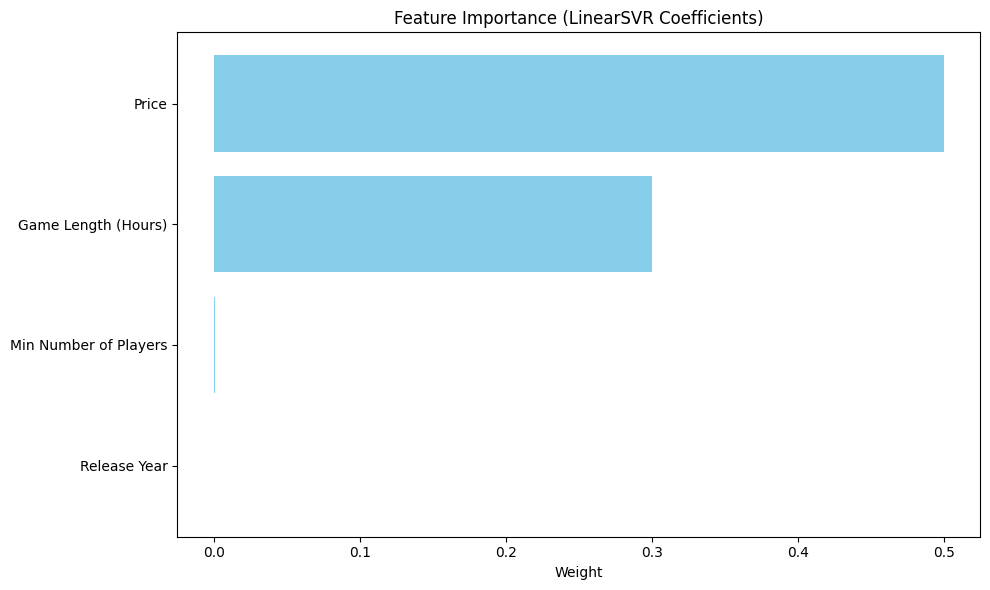

In [15]:
# Get the coefficients (weights) from the trained LinearSVR model
weights = simple_svm.coef_

# Get the names of the features
feature_names = X_train.columns

# Create a DataFrame for easy plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': weights
})

# Sort by absolute weight (importance)
coef_df['AbsWeight'] = np.abs(coef_df['Weight'])
coef_df = coef_df.sort_values(by='AbsWeight', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Weight'], color='skyblue')
plt.xlabel('Weight')
plt.title('Feature Importance (LinearSVR Coefficients)')
plt.gca().invert_yaxis()  # Highest importance on top
plt.tight_layout()
plt.show()